In [20]:
import os
import cv2
import numpy as np
import pandas as  pd
from matplotlib import pyplot as plt

In [21]:
all_embed = 'output.csv'
gen_imgs_path = 'gen_images/'
gen_img_names = [os.path.join(gen_imgs_path, x) for x in os.listdir(gen_imgs_path)]

,train_images/Abdullah_al-Attiyah_0001.jpg,train_images/Abdullah_al-Attiyah_0002.jpg,train_images/Abdullah_al-Attiyah_0003.jpg,train_images/face_1.jpg,train_images/face_2.jpg
gen_images/Abdullah_al-Attiyah_0001.jpg,1.000000,0.477576,0.735857,0.338404,0.228799
gen_images/Abdullah_al-Attiyah_0002.jpg,0.477576,1.000000,0.742356,0.653180,0.348559
gen_images/Abdullah_al-Attiyah_0003.jpg,0.735857,0.742356,1.000000,0.446007,0.171687


In [35]:
def get_top_k(file_name, gen_img_names, n_max=1):
    df = pd.read_csv(file_name, index_col=0)
    df_rank = df.stack(dropna=False).groupby(level=0).rank\
               (ascending=False, method='first').unstack()
    selected = df_rank.le(n_max, axis=1)
    nan_df = df[selected]
    nan_df_t = nan_df.transpose()
    
    for g_index, gen_img_name in enumerate(gen_img_names):
        g = nan_df_t[gen_img_name].nlargest(n=n_max)
        g = pd.DataFrame(g)
        
        fig = plt.figure(figsize=(10,8))
        gen_img = cv2.imread(gen_img_name)
        gen_img = gen_img[:, :, ::-1]
        
        ax1 = fig.add_subplot(1,n_max+1,1)
        ax1.imshow(gen_img)
        ax1.set_title("Diffusion")
        ax1.axis('off')
            
        for i in np.arange(n_max):
            g1 = g.index[i]

            train_img1 = cv2.imread(g1)
            train_img1 = train_img1[:, :, ::-1]
            ax2 = fig.add_subplot(1,n_max+1,i+2)
            ax2.imshow(train_img1)
            ax2.set_title("Dataset")
            ax2.axis('off')
            
            f_name = 'output2/' + gen_img_name.split('/')[-1]
            fig.savefig(f_name)

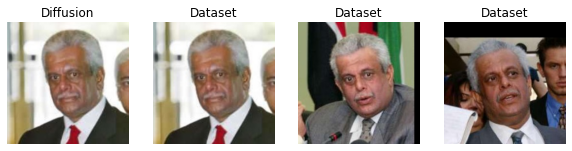

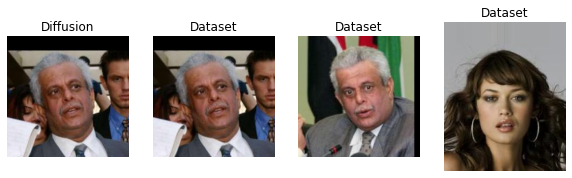

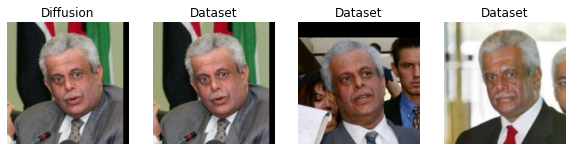

In [36]:
get_top_k(all_embed, gen_img_names, n_max=3)